In [1]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### t검정 예시 1 : compact vs suv의 도시 연비 t검정

In [9]:
# mpg 데이터 불러오기
import pandas as pd
mpg = pd.read_csv('mpg.csv')

# 기술 통계 분석
mpg.query('category in ["compact","suv"]') \
   .groupby('category', as_index = False) \
   .agg(n    = ('category', 'count'),
        mean = ('cty', 'mean'))

,category,n,mean
0,compact,47,20.12766
1,suv,62,13.50000


In [8]:
# compact와 suv 각각의 도시 연비 추출
compact = mpg.query('category == "compact"')['cty']
suv = mpg.query('category == "suv"')['cty']

# t-test 수행
from scipy import stats
stats.ttest_ind(compact, suv, equal_var = True)


TtestResult(statistic=np.float64(11.917282584324107), pvalue=np.float64(2.3909550904711282e-21), df=np.float64(107.0))

귀무가설 기각 -> compact와 suv 간 평균 도시 연비 차이가 통계적으로 유의하다

### t검정 예시 2 : 일반 휘발유 vs 고급 휘발유 t검정

In [6]:
# 기술 통계 분석
mpg.query('fl in ["r", "p"]') \
   .groupby('fl', as_index = False) \
   .agg(n    = ('fl', 'count'),
        mean = ('cty', 'mean'))

,fl,n,mean
0,p,52,17.365385
1,r,168,16.738095


In [7]:
# 연료 종류별 cty 추출
regular = mpg.query('fl == "r"')['cty']
premium = mpg.query('fl == "p"')['cty']

# t-test
stats.ttest_ind(regular, premium, equal_var = True)


TtestResult(statistic=np.float64(-1.066182514588919), pvalue=np.float64(0.28752051088667036), df=np.float64(218.0))

귀무가설 기각 불가 -> 도시 연비 차이가 통계적으로 유의하지 않다

### 상관분석

#### 실업자 수와 개인 소비 지출의 상관관계

In [4]:
# economics 데이터 불러오기
economics = pd.read_csv('economics.csv')

# 상관행렬 만들기
economics[['unemploy', 'pce']].corr()

,unemploy,pce
unemploy,1.000000,0.614518
pce,0.614518,1.000000


정비례 관계임을 파악함

In [5]:
# 상관분석
from scipy import stats
stats.pearsonr(economics['unemploy'], economics['pce'])

PearsonRResult(statistic=np.float64(0.614517614193208), pvalue=np.float64(6.773527303290177e-61))

귀무가설 기각 -> 실업자 수와 개인 소비 지출의 상관관계가 통계적으로 유의

#### 상관행렬 히트맵 만들기

In [11]:
# mtcars 데이터 불러오기
mtcars = pd.read_csv('mtcars.csv')

car_cor = mtcars.corr()
car_cor = round(car_cor, 2)
car_cor

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.00,-0.85,-0.85,-0.78,0.68,-0.87,0.42,0.66,0.60,0.48,-0.55
cyl,-0.85,1.00,0.90,0.83,-0.70,0.78,-0.59,-0.81,-0.52,-0.49,0.53
disp,-0.85,0.90,1.00,0.79,-0.71,0.89,-0.43,-0.71,-0.59,-0.56,0.39
hp,-0.78,0.83,0.79,1.00,-0.45,0.66,-0.71,-0.72,-0.24,-0.13,0.75
drat,0.68,-0.70,-0.71,-0.45,1.00,-0.71,0.09,0.44,0.71,0.70,-0.09
wt,-0.87,0.78,0.89,0.66,-0.71,1.00,-0.17,-0.55,-0.69,-0.58,0.43
qsec,0.42,-0.59,-0.43,-0.71,0.09,-0.17,1.00,0.74,-0.23,-0.21,-0.66
vs,0.66,-0.81,-0.71,-0.72,0.44,-0.55,0.74,1.00,0.17,0.21,-0.57
am,0.60,-0.52,-0.59,-0.24,0.71,-0.69,-0.23,0.17,1.00,0.79,0.06
gear,0.48,-0.49,-0.56,-0.13,0.70,-0.58,-0.21,0.21,0.79,1.00,0.27


In [12]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 120,          # 해상도 설정
                    'figure.figsize': [7.5, 5.5] # 가로 세로 크기 설정
                   })


<Axes: >

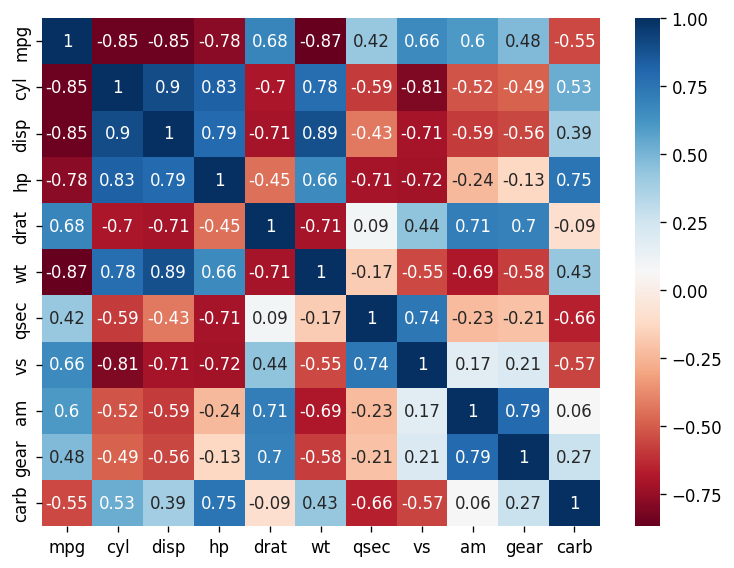

In [13]:
# 히트맵 만들기
import seaborn as sns
sns.heatmap(car_cor,          # 상관행렬 데이터
            annot = True,      # 상관계수 표시
            cmap = 'RdBu')     # 컬러맵

In [14]:
import numpy as np
mask = np.zeros_like(car_cor)
mask

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [15]:
mask[np.triu_indices_from(mask)] =1
mask

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

<Axes: >

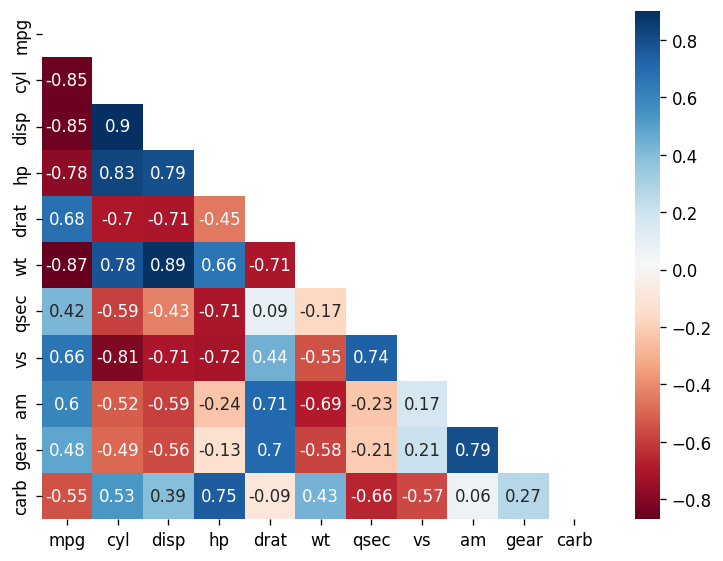

In [16]:
# mask 적용하기
sns.heatmap(data = car_cor,    # 상관행렬 데이터
            annot = True,      # 상관계수 표시
            cmap = 'RdBu',     # 컬러맵
            mask = mask)       # mask 적용


<Axes: >

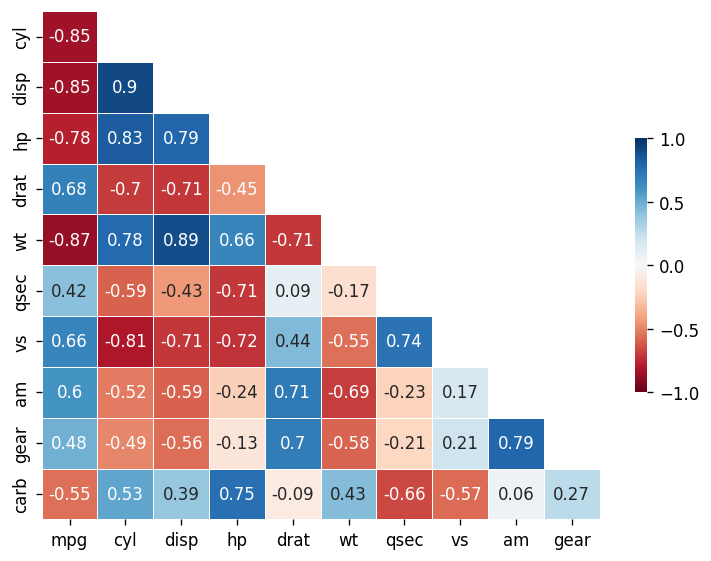

In [17]:
mask_new = mask[1:, :-1]             # mask의 첫 번째 행, 마지막 열 제거
cor_new = car_cor.iloc[1:, :-1]      # 상관행렬 첫 번째 행, 마지막 열 제거

# 히트맵 만들기
sns.heatmap(data = cor_new,          # 상관행렬 데이터
            annot = True,            # 상관계수 표시
            cmap = 'RdBu',           # 컬러맵
            mask = mask_new,         # mask 적용
            linewidths = .5,         # 경계 구분선 추가
            vmax = 1,                # 가장 진한 파란색으로 표현할 최대값
            vmin = -1,               # 가장 진한 빨간색으로 표현할 최소값
            cbar_kws = {'shrink': .5}) # 범례 크기 줄이기
